<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/logistic_regression_english_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression Fundamentals**
## **Gradient Descent vs Scikit-learn on Medical Diagnosis**
---

## Table of Contents

1. Introduction: What is Logistic Regression?
2. Data Preparation
3. Model Fundamentals
4. Manual Implementation with Gradient Descent
5. Manual Prediction and Evaluation
6. Implementation with Scikit-learn
7. Conclusions

---

## **1. Introduction: What is Logistic Regression?**

**Logistic Regression** is one of the most fundamental and widely used algorithms in Machine Learning for **classification** problems. Despite its name, it's not used for regression but for classification: predicting categories or classes.

### Why is it called "Regression" if it's Classification?

The name may seem confusing at first. Logistic regression is called that because it internally uses a linear regression function, but then transforms its output through the **sigmoid function** to obtain probabilities between 0 and 1. These probabilities are ultimately converted into discrete classes.

### Key Differences with Linear Regression

| Aspect | Linear Regression | Logistic Regression |
|---------|------------------|---------------------|
| **Objective** | Predict continuous values | Predict categories/classes |
| **Output** | Any real number | Probability between 0 and 1 |
| **Example** | Predict house price | Predict if a tumor is malignant or benign |
| **Function** | $y = w^T x + b$ | $P(y=1) = \sigma(w^T x + b)$ |

### Our Use Case: Breast Cancer Diagnosis

In this article we'll work with the **Wisconsin Breast Cancer Dataset**, one of the most widely used datasets in medical Machine Learning. Our goal is to classify tumors as:

- **Class 0**: Malignant (cancerous)
- **Class 1**: Benign (non-cancerous)

The dataset contains 30 numerical features calculated from digitized images of fine needle aspirates of breast masses. These features describe properties of the cell nuclei present in the image.

**Note about labels:**  
In this dataset (as loaded from the `scikit-learn` library), class 1 corresponds to *benign* and 0 to *malignant*. This assignment is **contrary to the usual medical convention**, where typically 1 indicates "disease present" (malignant) and 0 "absent" (benign). To maintain consistency with the source, we'll respect the dataset's encoding, but it's important to keep this difference in criteria in mind.

### Why is Logistic Regression important?
Although more sophisticated algorithms exist like Neural Networks or Gradient Boosting (tree ensembles), Logistic Regression remains extremely valuable because:

- **Simplicity**: Easy to implement and understand
- **Interpretability**: The weights tell us which features are most important
- **Efficiency**: Very fast to train, even with large datasets
- **Solid baseline**: Excellent starting point before trying complex models
- **Competitive results**: For many linearly separable problems, it achieves accuracy similar to more complex models

**Let's get started!** In the next section we'll load and explore our medical dataset.

---

## **2. Data Preparation**

In this section we'll load the **Wisconsin Breast Cancer** dataset, explore its main characteristics, perform manual splitting into training and test sets, and normalize the data to ensure stable training.

### 2.1 Loading the Dataset

The dataset is available directly in Scikit-learn, which makes it easy to access:

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()

# Create arrays for features and labels
X = data.data      # 569 samples x 30 features
y = data.target    # 569 labels (0: malignant, 1: benign)

# Create DataFrame for better visualization (optional)
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

Dataset shape: (569, 30)
Number of samples: 569
Number of features: 30


### 2.2 Basic Exploration

Let's look at the class distribution and some basic statistics:

In [2]:
# Class distribution
unique, counts = np.unique(y, return_counts=True)
print("\nClass distribution:")
print(f"Malignant (0): {counts[0]} ({counts[0]/len(y)*100:.1f}%)")
print(f"Benign (1): {counts[1]} ({counts[1]/len(y)*100:.1f}%)")

# First 5 features of the dataset
print("\nFirst 5 features:")
print(data.feature_names[:5])

# Basic statistics of the first 5 features
print("\nBasic statistics:")
print(df.iloc[:, :5].describe())


Class distribution:
Malignant (0): 212 (37.3%)
Benign (1): 357 (62.7%)

First 5 features:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']

Basic statistics:
       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.110000     39.280000      188.500000  2501.000000         0.163400


The dataset is relatively balanced, with approximately 63% benign cases and 37% malignant.

### 2.3 Manual Train-Test Split

Now we will manually split the data into training (80%) and test (20%) sets. It's important to shuffle the data before splitting to avoid biases.

In [3]:
# Set seed for reproducibility
np.random.seed(42)

# Total number of samples
n_samples = X.shape[0]

# Create random indices
indices = np.random.permutation(n_samples)

# Calculate split point (80% train, 20% test)
split_point = int(n_samples * 0.8)

# Split indices
train_indices = indices[:split_point]
test_indices = indices[split_point:]

# Create training and test sets
X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Train/test ratio: {X_train.shape[0]/X_test.shape[0]:.1f}")

Training samples: 455
Test samples:     114
Train/test ratio: 4.0


### 2.4 Why Shuffling is Important

Shuffling the data before splitting is crucial because:

- The data might be ordered by class (all malignant first, then benign)
- Without shuffling, the training set might not be representative
- It ensures both sets have a similar class distribution

We verify the distribution in both sets:

In [4]:
print("\nDistribution in training set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
print(f"Malignant: {counts_train[0]} ({counts_train[0]/len(y_train)*100:.1f}%)")
print(f"Benign:    {counts_train[1]} ({counts_train[1]/len(y_train)*100:.1f}%)")

print("\nDistribution in test set:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
print(f"Malignant: {counts_test[0]} ({counts_test[0]/len(y_test)*100:.1f}%)")
print(f"Benign:    {counts_test[1]} ({counts_test[1]/len(y_test)*100:.1f}%)")


Distribution in training set:
Malignant: 165 (36.3%)
Benign:    290 (63.7%)

Distribution in test set:
Malignant: 47 (41.2%)
Benign:    67 (58.8%)


The distributions should be similar in both sets, confirming that the split was correct.

### 2.5 Feature Normalization

Normalization is a **crucial** step in logistic regression. Notice the difference in scales in our dataset:

- `mean radius`: range [6.98, 28.11]
- `mean area`: range [143.5, 2501.0]
- `mean smoothness`: range [0.05, 0.16]

Without normalization:
- Features with large values dominate the gradient calculation
- Numerical problems occur (overflow in the exponential function)
- Convergence is slow or unstable

**Standardization method (Z-score):**

$$x_{normalized} = \frac{x - \mu}{\sigma}$$

Where $\mu$ is the mean and $\sigma$ is the standard deviation. This transforms all features to have mean 0 and standard deviation 1, improving the numerical stability of the algorithm.

In [5]:
# Calculate mean and standard deviation ONLY from the training set
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

# Normalize training set
X_train_norm = (X_train - mean_train) / std_train

# Normalize test set using the same parameters
X_test_norm = (X_test - mean_train) / std_train # ATTENTION: use train mean and std

print("\nNormalization completed:")
print(f"Shape of X_train_norm: {X_train_norm.shape}")
print(f"Mean of X_train_norm: {X_train_norm.mean():.6f} (should be ~0)")
print(f"Std of X_train_norm:   {X_train_norm.std():.6f} (should be ~1)")
print(f"\nBefore - X_train range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"After - X_train_norm range: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")


Normalization completed:
Shape of X_train_norm: (455, 30)
Mean of X_train_norm: 0.000000 (should be ~0)
Std of X_train_norm:   1.000000 (should be ~1)

Before - X_train range: [0.00, 3432.00]
After - X_train_norm range: [-3.14, 11.36]


**Note:** Ranges may vary depending on the random data split, but the mean and standard deviation of the normalized training set will always be ~0 and ~1 respectively.

**Important:**
- Always calculate normalization parameters using **only the training set**.
- Apply them to both the training and test sets.
- Never use unnormalized data to train or predict with the manual model.
- This prevents **data leakage** (information leak from training to test) and convergence problems.

### 2.6 Visualization of Normalization Effect

Let's visualize the impact of normalization on the first 5 features:

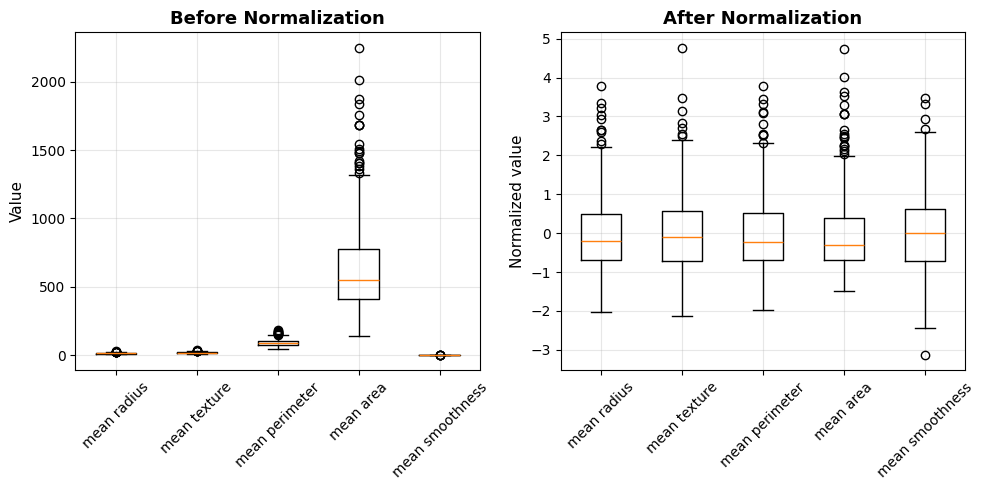

In [6]:
# Compare distributions before and after normalization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Before normalization
axes[0].boxplot(X_train[:, :5], tick_labels=data.feature_names[:5])
axes[0].set_title('Before Normalization', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# After normalization
axes[1].boxplot(X_train_norm[:, :5], tick_labels=data.feature_names[:5])
axes[1].set_title('After Normalization', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Normalized value', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Now all features are on the same scale, allowing the gradient descent algorithm to work optimally.

With the data properly prepared, split, and normalized, we are ready to build our logistic regression model from scratch. In the next section we will explore the mathematical foundations of the model.

---

## **3. Model Fundamentals**

In this section we will understand the three essential components of logistic regression: the sigmoid function, the cost function, and gradient descent.

### 3.1 The Sigmoid Function

Logistic regression uses the **sigmoid function** (also called logistic function) to convert any real value into a probability between 0 and 1.

**Mathematical definition:**

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z = w^T x + b$ is the linear combination of features.

**Note on notation:**
The term $b$ is called the **intercept** or *bias*. In some notations it is represented as $w_0$, which allows us to write the combination as:

$$z = w^T x + b = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n$$

This way, $z$ defines a **hyperplane** in the feature space.

**Application in the model:**

Logistic regression takes this $z$ and passes it through the sigmoid function:

$$P(y=1|x) = \sigma(z) = \frac{1}{1 + e^{-(w^T x + b)}}$$

This formula tells us: "the probability that the class is 1, given the input $x$, is the result of applying the sigmoid to the linear combination of features $z$".

**Python implementation:**

In [7]:
def sigmoid(z):
    """
    Calculate the sigmoid function

    Parameters:
    z: real value

    Returns:
    Probability between 0 and 1
    """
    return 1 / (1 + np.exp(-z))

**Visualization of the sigmoid function:**

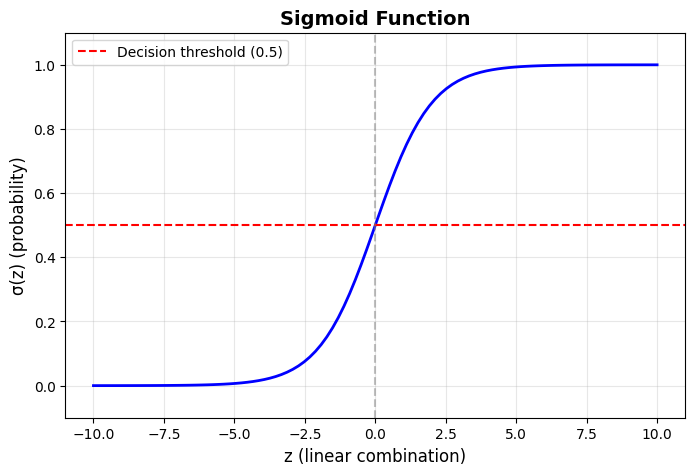

In [8]:
# Create z values between -10 and 10
z = np.linspace(-10, 10, 100)
sigma_z = sigmoid(z)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(z, sigma_z, linewidth=2, color='blue')
plt.axhline(y=0.5, color='red', linestyle='--', label='Decision threshold (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('z (linear combination)', fontsize=12)
plt.ylabel('σ(z) (probability)', fontsize=12)
plt.title('Sigmoid Function', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.ylim(-0.1, 1.1)
plt.show()

**Important properties:**

- When $z \to \infty$, then $\sigma(z) \to 1$
- When $z \to -\infty$, then $\sigma(z) \to 0$
- When $z = 0$, then $\sigma(z) = 0.5$ → decision threshold
- The function is symmetric around the point (0, 0.5)

### 3.2 From Probabilities to Classes

The sigmoid function gives us the probability that a sample belongs to the positive class (1). To convert this probability into a class prediction, we use a **decision threshold**:

$$\hat{y} = \begin{cases}
1 & \text{if } \sigma(z) \geq 0.5 \\
0 & \text{if } \sigma(z) < 0.5
\end{cases}$$

In [9]:
def predict(X, w, b):
    """
    Calculate binary predictions

    Parameters:
    X: features (n_samples, n_features)
    w: weights (n_features,)
    b: bias (scalar)

    Returns:
    Binary predictions (0 or 1)
    """
    z = X @ w + b   # Equivalent to w^T x + b
    probabilities = sigmoid(z)
    predictions = (probabilities >= 0.5).astype(int)
    return predictions

### 3.3 The Cost Function (Log Loss)

To train the model we need a function that measures how far our predictions are from the actual values. In logistic regression we use the **logarithmic loss function** (Log Loss):

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Where:
- $m$ is the number of training samples
- $y^{(i)}$ is the true label (0 or 1) of sample $i$
- $\hat{y}^{(i)} = \sigma(w^T \cdot x^{(i)} + b)$ is the predicted probability (between 0 and 1)

**Intuition:**

The cost function $J$ is symmetric and heavily penalizes **incorrect predictions**, whether false positives or false negatives. For example:
- If the true value is $y=1$ but we predict $\hat{y}=0$, then $\log(0) \to -\infty$. The negative sign transforms it to $+\infty$, an infinite penalty.
- If the true value is $y=0$ but we predict $\hat{y}=1$, the same happens: $\log(1-1) = \log(0) \to -\infty$, which becomes $+\infty$.

In practice, since $\hat{y}$ is a probability, it will rarely be exactly 0 or 1, but extreme values like 0.001 or 0.999 still generate very high penalties.

**The goal of training is to find the parameters $(w, b)$ that minimize this average cost.**

> We might think of using mean squared error (as in linear regression), but this doesn't work well here. Log Loss is the correct function because it is directly derived from the maximum likelihood principle for classification, and its form **exponentially penalizes confident but incorrect predictions**, thus better guiding the training.

**Implementation:**

In [10]:
def compute_cost(X, y, w, b):
    """
    Calculate the cost function (Log Loss)

    Parameters:
    X: features (n_samples, n_features)
    y: true labels (n_samples,)
    w: weights (n_features,)
    b: bias (scalar)

    Returns:
    Average cost
    """
    m = X.shape[0]
    z = X @ w + b
    y_pred = sigmoid(z)

    # We use clip for numerical stability: avoids log(0) = -∞
    epsilon = 1e-15     # we use a very small value
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    cost = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    return cost

The goal of training is to minimize this cost.

### 3.4 Introduction to Gradient Descent

**Gradient Descent** is the optimization algorithm we will use to find the best values of $w$ and $b$ that minimize the cost function.

**Intuitive idea:**

Imagine you're at the top of a mountain shrouded in fog and want to reach the valley (lowest point). Gradient descent works like this:

1. You look around and determine the direction of steepest downward slope
2. You take a step in that direction
3. You repeat the process until you reach the valley

**Parameter update:**

In each iteration, we update the weights and bias using these formulas:

$$w := w - \alpha \frac{\partial J}{\partial w}$$

$$b := b - \alpha \frac{\partial J}{\partial b}$$

Where:
- $\alpha$ is the **learning rate**: controls the step size
- $\frac{\partial J}{\partial w}$ and $\frac{\partial J}{\partial b}$ are the partial derivatives that form the gradient vector

**Gradient calculation:**

For logistic regression, the partial derivatives that form the gradient are:

$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{y} - y)$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

In [11]:
def compute_gradients(X, y, w, b):
    """
    Calculate the gradients of the cost function

    Parameters:
    X: features (n_samples, n_features)
    y: true labels (n_samples,)
    w: weights (n_features,)
    b: bias (scalar)

    Returns:
    dw: gradient with respect to w
    db: gradient with respect to b
    """
    m = X.shape[0]
    z = X @ w + b
    y_pred = sigmoid(z)

    dw = (1/m) * X.T @ (y_pred - y)
    db = (1/m) * np.sum(y_pred - y)

    return dw, db

**Important parameters:**

- **Learning rate (α)**: If it's too large, we can "jump over" the minimum; if it's too small, training will be very slow. Typical values: 0.001, 0.01, 0.1
- **Number of iterations**: How many times we will update the parameters. Typical values: 1000, 5000, 10000

With these fundamentals clear, in the next section we will implement the complete gradient descent algorithm to train our model from scratch.

---

## **4. Manual Implementation with Gradient Descent**

In this section we will implement the complete logistic regression algorithm from scratch, training the model with gradient descent using normalized data and visualizing the learning process.

### 4.1 Complete Training Function

We will create a function that integrates all the components we saw in the previous section:

In [12]:
def train_logistic_regression(X, y, learning_rate=0.01, n_iterations=1000):
    """
    Train a logistic regression model using gradient descent

    Parameters:
    X: normalized features (n_samples, n_features)
    y: true labels (n_samples,)
    learning_rate: learning rate (alpha)
    n_iterations: number of algorithm iterations

    Returns:
    w: trained weights
    b: trained bias
    costs: cost history (for visualization)
    """
    # Get dimensions
    n_samples, n_features = X.shape

    # Initialize parameters to zero
    w = np.zeros(n_features)
    b = 0

    # List to store cost history
    costs = []

    # Gradient descent algorithm
    for i in range(n_iterations):
        # 1. Compute predictions
        z = X @ w + b
        y_pred = sigmoid(z)

        # 2. Compute gradients (using previously defined function)
        dw, db = compute_gradients(X, y, w, b)

        # 3. Update parameters
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # 4. Compute and save cost every 100 iterations
        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            costs.append(cost)
            print(f"Iteration {i}: Cost = {cost:.4f}")

    return w, b, costs

**Note on the type of Gradient Descent used**

Our implementation uses **Batch Gradient Descent**, which computes the gradient using *all* the training data in each iteration. Other variants exist such as **Stochastic Gradient Descent (SGD)**, which uses one random sample per iteration, and **Mini-Batch Gradient Descent**, which uses small groups of samples. Batch GD is more stable but slower on very large datasets.

### 4.2 Model Training

Now we will train our model with the training data:

In [13]:
# Configure training parameters
learning_rate = 0.01
n_iterations = 2000

# Train the model with NORMALIZED data
print("Starting training...")
print("-" * 50)
w_trained, b_trained, cost_history = train_logistic_regression(
    X_train_norm,  # We use normalized data
    y_train,
    learning_rate=learning_rate,
    n_iterations=n_iterations
)
print("-" * 50)
print("Training completed!")

Starting training...
--------------------------------------------------
Iteration 0: Cost = 0.6727
Iteration 100: Cost = 0.2414
Iteration 200: Cost = 0.1786
Iteration 300: Cost = 0.1499
Iteration 400: Cost = 0.1328
Iteration 500: Cost = 0.1213
Iteration 600: Cost = 0.1130
Iteration 700: Cost = 0.1065
Iteration 800: Cost = 0.1014
Iteration 900: Cost = 0.0972
Iteration 1000: Cost = 0.0936
Iteration 1100: Cost = 0.0906
Iteration 1200: Cost = 0.0880
Iteration 1300: Cost = 0.0858
Iteration 1400: Cost = 0.0837
Iteration 1500: Cost = 0.0819
Iteration 1600: Cost = 0.0803
Iteration 1700: Cost = 0.0788
Iteration 1800: Cost = 0.0775
Iteration 1900: Cost = 0.0763
--------------------------------------------------
Training completed!


We observe that the cost decreases consistently, indicating that the model is learning correctly.

### 4.3 Convergence Visualization

It's important to visualize how the cost evolves during training to verify that the algorithm converges correctly:

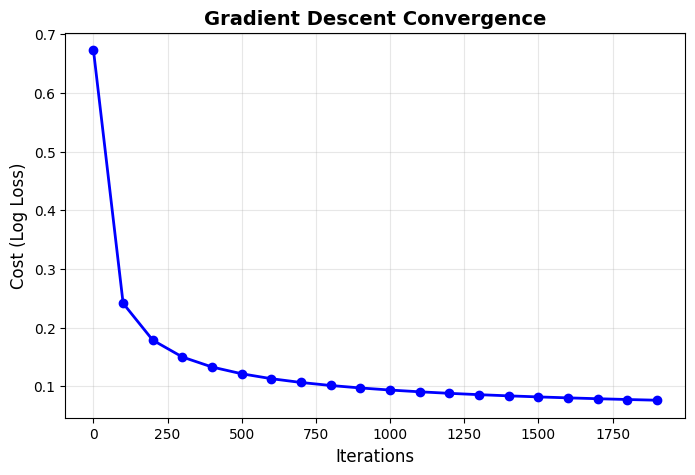

In [14]:
# Create convergence plot
plt.figure(figsize=(8, 5))
iterations = np.arange(0, n_iterations, 100)
plt.plot(iterations, cost_history, linewidth=2, color='blue', marker='o')
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Cost (Log Loss)', fontsize=12)
plt.title('Gradient Descent Convergence', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation:**

- This smooth curve confirms that normalization worked correctly
- Initially, the cost decreases rapidly
- Then the decrease becomes more gradual until it stabilizes

### 4.4 Prediction Function

We create a function to make predictions with our trained model:

In [15]:
def predict_manual(X, w, b):
    """
    Make predictions with the trained model

    Parameters:
    X: normalized features (n_samples, n_features)
    w: trained weights
    b: trained bias

    Returns:
    predictions: predicted classes (0 or 1)
    probabilities: probabilities of the positive class
    """
    z = X @ w + b
    probabilities = sigmoid(z)
    predictions = (probabilities >= 0.5).astype(int)
    return predictions, probabilities

### 4.5 Predictions on the Training Set

We verify performance on the normalized training data:

In [16]:
# Make predictions on the normalized training set
y_train_pred, y_train_prob = predict_manual(X_train_norm, w_trained, b_trained)

# Calculate accuracy manually
train_accuracy = np.mean(y_train_pred == y_train)
print(f"Training accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

# Show some predictions
print("\nPrediction examples (first 5 samples):")
print("Actual | Predicted | Probability")
print("-" * 35)
for i in range(5):
    print(f"  {y_train[i]}  |    {y_train_pred[i]}     |    {y_train_prob[i]:.4f}")

Training accuracy: 0.9890 (98.90%)

Prediction examples (first 5 samples):
Actual | Predicted | Probability
-----------------------------------
  1  |    1     |    0.8484
  0  |    0     |    0.0006
  0  |    0     |    0.0288
  1  |    1     |    0.9863
  1  |    1     |    0.9978


In the next section we will evaluate the model on the normalized test set to obtain a more realistic measure of its generalization capability.

---

## **5. Manual Prediction and Evaluation**

In this section we will evaluate our manually trained model using the normalized test set. It's crucial to evaluate on data that the model has not seen during training to obtain a realistic estimate of its generalization capability.

### 5.1 Predictions on the Test Set

We apply our trained model to the normalized test data:

In [17]:
# Predictions on test (always with normalized data)
y_test_pred, y_test_prob = predict_manual(X_test_norm, w_trained, b_trained)

print("Predictions on the test set:")
print(f"Total samples: {len(y_test)}")
print(f"Positive predictions (benign):    {np.sum(y_test_pred)}")
print(f"Negative predictions (malignant): {np.sum(y_test_pred == 0)}")

Predictions on the test set:
Total samples: 114
Positive predictions (benign):    69
Negative predictions (malignant): 45


### 5.2 Accuracy Calculation

**Accuracy** is the simplest and most common metric for evaluating classification models. It measures the proportion of correct predictions over the total predictions.

**Accuracy Formula:**

$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

Where:
- **TP** (True Positives): Correct predictions of the positive class
- **TN** (True Negatives): Correct predictions of the negative class
- **FP** (False Positives): Incorrect predictions as positive
- **FN** (False Negatives): Incorrect predictions as negative

**Manual implementation:**

In [18]:
def calculate_accuracy(y_true, y_pred):
    """
    Calculate accuracy manually

    Parameters:
    y_true: true labels
    y_pred: predicted labels

    Returns:
    accuracy: proportion of correct predictions
    """
    correct_predictions = np.sum(y_true == y_pred)
    total_predictions = len(y_true)
    accuracy = correct_predictions / total_predictions
    return accuracy

# Calculate accuracy
test_accuracy = calculate_accuracy(y_test, y_test_pred)

print(f"\nAccuracy on test set: {test_accuracy:.4f}")
print(f"Correct classification rate: {test_accuracy * 100:.2f}%")
print(f"Correct predictions: {np.sum(y_test == y_test_pred)} out of {len(y_test)}")


Accuracy on test set: 0.9649
Correct classification rate: 96.49%
Correct predictions: 110 out of 114


### 5.3 Manual Confusion Matrix

The confusion matrix allows us to see in detail what types of errors our model makes:

In [19]:
def calculate_confusion_matrix(y_true, y_pred):
    """
    Calculate the confusion matrix manually

    Returns:
    tn, fp, fn, tp
    """
    tn = np.sum((y_true == 0) & (y_pred == 0))  # True Negatives
    fp = np.sum((y_true == 0) & (y_pred == 1))  # False Positives
    fn = np.sum((y_true == 1) & (y_pred == 0))  # False Negatives
    tp = np.sum((y_true == 1) & (y_pred == 1))  # True Positives
    return tn, fp, fn, tp

# Calculate confusion matrix
tn, fp, fn, tp = calculate_confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:")
print("                   Predicted")
print("                Malignant  Benign")
print(f"True  Malignant      {tn}       {fp}")
print(f"      Benign          {fn}      {tp}")


Confusion Matrix:
                   Predicted
                Malignant  Benign
True  Malignant      44       3
      Benign          1      66


**Interpretation:**

- **True Negatives (44)**: Malignant tumors correctly identified
- **True Positives (66)**: Benign tumors correctly identified
- **False Positives (3)**: Malignant tumors classified as benign → **SERIOUS ERROR** (failing to detect real cancer)
- **False Negatives (1)**: Benign tumors classified as malignant → generates anxiety and unnecessary tests

In medical diagnosis, False Positives (failing to detect real cancer) are more serious than False Negatives (false alarm).

### 5.4 Comparison: Training vs Test

Let's compare the performance on both sets:

In [20]:
print("\n" + "="*50)
print("EVALUATION SUMMARY - MANUAL MODEL")
print("="*50)
print(f"TRAINING Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"TEST Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Difference:        {abs(train_accuracy - test_accuracy):.4f}")
print("="*50)

if abs(train_accuracy - test_accuracy) < 0.05:
    print("The model generalizes well (difference < 5%)")
else:
    print("Possible overfitting (difference >= 5%)")


EVALUATION SUMMARY - MANUAL MODEL
TRAINING Accuracy: 0.9890 (98.90%)
TEST Accuracy:     0.9649 (96.49%)
Difference:        0.0241
The model generalizes well (difference < 5%)


In the next section we will implement the same solution with Scikit-learn and compare the results.

---

## **6. Implementation with Scikit-learn**

In this section we will see how to solve the same problem using Scikit-learn, the standard Machine Learning library in Python. We will use normalized data and compare the results with our manual implementation.

### 6.1 Data Split with train_test_split

Scikit-learn provides `train_test_split`, a function that simplifies splitting data into training and test sets.

In [21]:
from sklearn.model_selection import train_test_split

# Split data (80% train, 20% test)
X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintains class proportions
)

print("Split with Scikit-learn:")
print(f"Training: {X_train_sk.shape[0]} samples")
print(f"Test: {X_test_sk.shape[0]} samples")

Split with Scikit-learn:
Training: 455 samples
Test: 114 samples


**Advantages over manual splitting:**

- **stratify**: Ensures both sets have the same class proportions, especially useful in imbalanced datasets
- **random_state**: Allows reproducibility in results
- **Cleaner code**: One line vs multiple steps

### 6.2 Normalization with StandardScaler

Scikit-learn provides `StandardScaler` to normalize data professionally:

In [22]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit and transform the training set
X_train_sk_scaled = scaler.fit_transform(X_train_sk)

# Transform the test set (using parameters from train)
X_test_sk_scaled = scaler.transform(X_test_sk)

print("\nNormalization with StandardScaler:")
print(f"Mean of X_train_sk_scaled: {X_train_sk_scaled.mean():.6f}")
print(f"Std of X_train_sk_scaled: {X_train_sk_scaled.std():.6f}")


Normalization with StandardScaler:
Mean of X_train_sk_scaled: -0.000000
Std of X_train_sk_scaled: 1.000000


**Important:**
- `fit_transform()` calculates the parameters (mean, std) and transforms in one step
- `transform()` only transforms using already calculated parameters
- Never use `fit_transform()` on the test set

### 6.3 Model Creation and Training

Creating and training a model with Scikit-learn is extremely simple:

In [23]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(random_state=42, max_iter=2000)

# Train the model with normalized data
model.fit(X_train_sk_scaled, y_train_sk)

print("Model trained successfully!")
print(f"Number of iterations performed: {model.n_iter_[0]}")

Model trained successfully!
Number of iterations performed: 19


Notice that Scikit-learn converges in fewer iterations thanks to internal optimizations and more sophisticated algorithms.

### 6.4 Predictions and Probabilities

In [24]:
# Make predictions on normalized data
y_train_pred_sk = model.predict(X_train_sk_scaled)
y_test_pred_sk = model.predict(X_test_sk_scaled)

# Get probabilities
y_test_prob_sk = model.predict_proba(X_test_sk_scaled)[:, 1]  # Probability class 1

print("Prediction examples (first 5 test samples):")
print("Actual | Predicted | Probability")
print("-" * 35)
for i in range(5):
    print(f"  {y_test_sk[i]}    |    {y_test_pred_sk[i]}      |    {y_test_prob_sk[i]:.4f}")

Prediction examples (first 5 test samples):
Actual | Predicted | Probability
-----------------------------------
  0    |    0      |    0.0000
  1    |    1      |    1.0000
  0    |    0      |    0.0064
  1    |    1      |    0.5335
  0    |    0      |    0.0000


### 6.5 Evaluation with Scikit-learn

In [25]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
train_accuracy_sk = accuracy_score(y_train_sk, y_train_pred_sk)
test_accuracy_sk = accuracy_score(y_test_sk, y_test_pred_sk)

print("\n" + "="*50)
print("EVALUATION - SCIKIT-LEARN MODEL")
print("="*50)
print(f"TRAINING Accuracy: {train_accuracy_sk:.4f} ({train_accuracy_sk*100:.2f}%)")
print(f"TEST Accuracy:     {test_accuracy_sk:.4f} ({test_accuracy_sk*100:.2f}%)")
print("="*50)


EVALUATION - SCIKIT-LEARN MODEL
TRAINING Accuracy: 0.9890 (98.90%)
TEST Accuracy:     0.9825 (98.25%)


### 6.6 Confusion Matrix with Scikit-learn

In [26]:
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test_sk, y_test_pred_sk)

print("\nConfusion Matrix (Scikit-learn):")
print("                   Predicted")
print("                Malignant  Benign")
print(f"Actual  Malignant      {cm[0,0]}       {cm[0,1]}")
print(f"        Benign          {cm[1,0]}      {cm[1,1]}")


Confusion Matrix (Scikit-learn):
                   Predicted
                Malignant  Benign
Actual  Malignant      41       1
        Benign          1      71


### 6.7 Comparison: Manual vs Scikit-learn

Let's compare both implementations side by side:

In [27]:
print("\n" + "="*60)
print("COMPARISON: MANUAL IMPLEMENTATION vs SCIKIT-LEARN")
print("="*60)
print(f"{'Metric':<30} {'Manual':<13} {'Scikit-learn'}")
print("-"*60)
print(f"{'Training Accuracy':<30} {train_accuracy:.4f}        {train_accuracy_sk:.4f}")
print(f"{'Test Accuracy':<30} {test_accuracy:.4f}        {test_accuracy_sk:.4f}")
print(f"{'Iterations':<30} {n_iterations:<15} {model.n_iter_[0]:<15}")
print(f"{'Normalization':<30} {'Manual':<13} {'StandardScaler'}")
print("="*60)

# Results analysis
diff_train = abs(train_accuracy - train_accuracy_sk)
diff_test = abs(test_accuracy - test_accuracy_sk)

print("\nAnalysis:")
if test_accuracy_sk > test_accuracy:
    print(f"Scikit-learn improves test accuracy by {(test_accuracy_sk - test_accuracy)*100:.2f}%")
    print("This is due to solver optimizations and better convergence.")
elif test_accuracy > test_accuracy_sk:
    print(f"The manual implementation achieves better test accuracy by {(test_accuracy - test_accuracy_sk)*100:.2f}%")
else:
    print("Both implementations achieve the same test accuracy.")

print(f"\nScikit-learn converges in {model.n_iter_[0]} iterations vs {n_iterations} from the manual implementation,")
print("demonstrating the efficiency of advanced optimization algorithms.")


COMPARISON: MANUAL IMPLEMENTATION vs SCIKIT-LEARN
Metric                         Manual        Scikit-learn
------------------------------------------------------------
Training Accuracy              0.9890        0.9890
Test Accuracy                  0.9649        0.9825
Iterations                     2000            19             
Normalization                  Manual        StandardScaler

Analysis:
Scikit-learn improves test accuracy by 1.75%
This is due to solver optimizations and better convergence.

Scikit-learn converges in 19 iterations vs 2000 from the manual implementation,
demonstrating the efficiency of advanced optimization algorithms.


**Conclusion:** Our manual implementation helped us understand the algorithm, but Scikit-learn is the professional choice due to its superior performance and efficiency.

### 6.8 Complete Minimal Code
For reference, here is the entire workflow with Scikit-learn in just a few lines:

In [28]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load and split data
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and predict
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9737


**Note:**

The accuracy here (0.9737) differs from the one obtained in section 6.7 (0.9825) because we use different data splits: section 6.7 uses the manual split from section 2.3, while here we use Scikit-learn's `train_test_split`. Although both use random seeds, the shuffling algorithms are different. The important thing is that both demonstrate excellent generalization (~96-98%).

Comparing with our manual implementation, Scikit-learn obtains better results thanks to its advanced optimizers. Still, our implementation achieves excellent accuracy, validating that we correctly understood the algorithm and the importance of normalization.

---

## **7. Conclusions**

We have completed a comprehensive journey through Logistic Regression, from its manual implementation to its professional use with Scikit-learn, applying it to breast cancer diagnosis.

### What have we learned?

In this article we have covered the theoretical fundamentals (sigmoid function, cost function, and gradient descent), implemented the complete algorithm from scratch, and verified that our implementation produces results similar to Scikit-learn.

### Advantages and Limitations

- **Advantages:** Simplicity, interpretability, fast training, and calibrated probabilities useful for decision-making.
- **Limitations:** Assumes linear relationships, sensitive to unnormalized features, and simple decision boundary.

### Extension to Multiclass Classification

Logistic regression can be extended to problems with more than two classes through two main strategies: One-vs-Rest (training one binary classifier per class) or multinomial logistic regression with Softmax function (which provides probabilities of belonging to each class). Scikit-learn implements both strategies transparently.

### When to Use Logistic Regression

It's ideal for binary classification with linearly separable data, when you need interpretability, as a baseline before complex models, or when you require calibrated probabilities. For complex nonlinear relationships, consider algorithms like Random Forest or Gradient Boosting.

### Key Lessons

- **Normalization is fundamental** to avoid numerical problems and achieve convergence.
- **Implementing from scratch teaches the fundamentals**, but professional libraries use superior optimizers that achieve better results.
- **Simplicity has value**: logistic regression achieved excellent accuracy on a real medical problem, demonstrating that complex models are not always necessary.

### Final Reflection

Logistic Regression is one of the pillars of Machine Learning. By implementing it from scratch, we can develop a deep understanding of fundamental concepts: cost functions, gradient-based optimization, normalization, and rigorous evaluation. This solid foundation will prepare us to tackle more advanced algorithms with confidence.

**Congratulations on completing this tutorial!** You now have the tools to apply Logistic Regression to your own classification problems and understand what happens internally in professional libraries.

---